
Questions:
1. Display Top 5 Rows of The Dataset
2. Check the Last 3 Rows of The Dataset
3. Find Shape of Our Dataset (Number of Rows & Number of Columns)
4. Get Information About Our Dataset Like Total Number Rows, Total Number of Columns, Datatypes of Each Column And Memory Requirement
5. Get Overall Statistics About The Dataframe
6. Total Number of App Titles Contain Astrology
7. Find Average App Rating
8.  Find Total Number of Unique Category
9. Which Category Getting The Highest Average Rating?
10. Find Total Number of App having 5 Star Rating
11. Find Average Value of Reviews
12. Find Total Number of Free and Paid Apps
13.  Which App Has Maximum Reviews?
14. Display Top 5 Apps Having Highest Reviews
15. Find Average Rating of Free and Paid Apps
16. Display Top  5 Apps Having Maximum Installs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


array([[<Axes: title={'center': 'Rating'}>]], dtype=object)

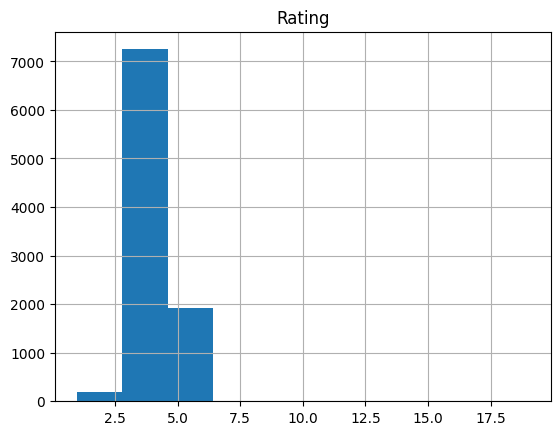

In [43]:
import pandas as pd

df = pd.read_csv('/content/googleplaystore.csv')

# Question 1 to 5
df.head(5)

df.tail(3)

df.shape

df.info()


df.describe()
df.hist()


In [44]:
df = df.drop_duplicates()

df.duplicated().sum()

df.dropna(inplace=True)

df.isna().sum()

/tmp/ipython-input-4034768086.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [45]:
# 6 to 10

df[df['App'].str.contains('Astrology')]

average_app_rating = df['Rating'].mean()
print(f"The average the app rating {average_app_rating}")

df['Category'].unique()

df.groupby('Category',as_index=False).agg({'Rating':pd.Series.mean}).sort_values('Rating',ascending=False).head(1)

The average the app rating 4.187958586540625


,Category,Rating
10,EVENTS,4.435556


In [52]:
# 11 to 14

df[df['Rating'] == 5.0].size

df['Reviews'] = df['Reviews'].replace('3.0M','3000000')
df['Reviews'] = pd.to_numeric(df['Reviews'])

df['Reviews'].mean()


df.groupby('Type').size().reset_index(name = 'count')

df.sort_values('Reviews',ascending=False).head(1)


df.sort_values('Reviews',ascending=False).head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2544,Facebook,SOCIAL,4.1,78158306,Varies with device,"1,000,000,000+",Free,0,Teen,Social,"August 3, 2018",Varies with device,Varies with device
3943,Facebook,SOCIAL,4.1,78128208,Varies with device,"1,000,000,000+",Free,0,Teen,Social,"August 3, 2018",Varies with device,Varies with device
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,Varies with device,"1,000,000,000+",Free,0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
3904,WhatsApp Messenger,COMMUNICATION,4.4,69109672,Varies with device,"1,000,000,000+",Free,0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
2604,Instagram,SOCIAL,4.5,66577446,Varies with device,"1,000,000,000+",Free,0,Teen,Social,"July 31, 2018",Varies with device,Varies with device


In [61]:
# 15 to 16

df.groupby('Type').agg({'Rating':pd.Series.mean})

# df['Installs'] = df['Installs'].str.replace('+',"")
# df['Installs'] = df['Installs'].str.replace(',',"")

df['Installs'] = df['Installs'].astype('float')

df.sort_values('Installs',ascending=False).head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
3232,Google Street View,TRAVEL_AND_LOCAL,4.2,2129707,Varies with device,1.000000e+09,Free,0,Everyone,Travel & Local,"August 6, 2018",Varies with device,Varies with device
3223,Maps - Navigate & Explore,TRAVEL_AND_LOCAL,4.3,9235373,Varies with device,1.000000e+09,Free,0,Everyone,Travel & Local,"July 31, 2018",Varies with device,Varies with device
9844,Google News,NEWS_AND_MAGAZINES,3.9,878065,13M,1.000000e+09,Free,0,Teen,News & Magazines,"August 1, 2018",5.2.0,4.4 and up
386,Hangouts,COMMUNICATION,4.0,3419433,Varies with device,1.000000e+09,Free,0,Everyone,Communication,"July 21, 2018",Varies with device,Varies with device
391,Skype - free IM & video calls,COMMUNICATION,4.1,10484169,Varies with device,1.000000e+09,Free,0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device


In [82]:
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


#plotting the number of installs based on reviews

query_1 = df.groupby('Rating',as_index=False).agg({'Installs':pd.Series.count})
query_1

fig = px.line(query_1,x='Rating',y='Installs',title='Installs based on reviews')
fig.update_layout(yaxis_title='Installs (in Millions)')

# Top categories of the apps made and people bought

query_2 = df.groupby('Category',as_index=False).size().rename(columns={'size':'APPS PRODUCED'}).sort_values('APPS PRODUCED',ascending=False).head(5)
fig2 = px.bar(query_2,orientation='h',x='APPS PRODUCED',y='Category',color='Category')
# fig2.show()



query_3 = df.groupby('Category',as_index=False).agg({'Installs':pd.Series.sum}).sort_values('Installs',ascending=False).head(5)
fig3 = px.bar(query_3,orientation='h',x='Installs',y='Category',color='Category')
fig3.show()






In [96]:
#plotting sales vs installs


query_4 = df.groupby('Type',as_index=False).agg({'Installs':pd.Series.sum}).sort_values('Installs',ascending=False)
fig4 = px.pie(query_4,names='Type',values='Installs')
fig4.show()

# Trends in rating


query_5 = df.groupby('Content Rating',as_index=False).agg({'Installs':pd.Series.sum}).sort_values('Installs',ascending=False)
fig5 = px.bar(query_5,x='Content Rating',y='Installs',color='Content Rating')
fig5.show()
